#  **Colab File for CNN training- *PyTorch***
Before you start please prepare the following:


1.   Uplaod the dataset as Zip file to GDrive
2.   Upload code files to GDrive



**Please MAKE sure that you are using GPU . Go to Runtime>> Change Runtime type  and select GPU**

#  **Connect to Google Drive**
 Allow Google Colab to connect to your GDrive

In [4]:
from google.colab import drive
drive.mount('/content/drive')
from IPython.display import clear_output

ModuleNotFoundError: No module named 'google.colab'

2- Change directory to where you want to keep your dataset

3 - Download Dataset

In [ ]:
# Download Dataset
from IPython.display import clear_output
# !pip install --upgrade --no-cache-dir gdown
#!gdown 1oKH1urVUELrrnQfDTPDt4Aj5H3NwNzn6 #0.4451, 0.4431, 0.4012 - 0.2162, 0.2093, 0.2245
!gdown 1swRiQZRCU3tjYotRIfdWSqSVVGN9RCoa

!jar xvf 'Data.zip'
clear_output()

In [ ]:
!rm -r 'Data.zip'

4 - Download Codes

In [ ]:
%cd /content/

In [ ]:
#!gdown --id 1GJc1zBMaY5tirewUOrKQcGv43SoaIVWS #1.6
!gdown 1rE78950bEEQd_1WZ80TUXPwcFj-zSyhV #2.0
!jar xvf '2D_Segmentation.zip'
clear_output()

In [ ]:
!rm -r '2D_Segmentation.zip'

# Install and Import Required Libraries (Conditionally Optional)
Use 'pip' to install libraries. Put '!' i.e. Exclamation Mark before each command, exclusive to Jupyter Notebooks. Some are already installed by Google Colab and others are required. If the IMPORT statements are present in the python code being run, no need to follow this step.

In [1]:
!pip install torch==1.12.1+cu116 torchvision==0.13.1+cu116 torchaudio==0.12.1 --extra-index-url https://download.pytorch.org/whl/cu116

#!pip3 install torch==1.9.0+cu111 torchvision==0.10.0+cu111 torchaudio==0.9.0 -f https://download.pytorch.org/whl/torch_stable.html
clear_output() #comment out to debug

# CudaVersion = !nvcc --version
# CudaVersion = CudaVersion[3].partition('V')[2][0:4]
# if CudaVersion == '11.0':
#   # CUDA 11.0
#   !pip install torch==1.7.1+cu110 torchvision==0.8.2+cu110 torchaudio==0.7.2 -f https://download.pytorch.org/whl/torch_stable.html
# elif CudaVersion == '10.2':
#   # CUDA 10.2
#   !pip install torch==1.7.1 torchvision==0.8.2 torchaudio==0.7.2
# elif CudaVersion == '10.1':
#   # CUDA 10.1
#   !pip install torch==1.7.1+cu101 torchvision==0.8.2+cu101 torchaudio==0.7.2 -f https://download.pytorch.org/whl/torch_stable.html
# else:
#   # CUDA 9.2
#   !pip install torch==1.7.1+cu92 torchvision==0.8.2+cu92 torchaudio==0.7.2 -f https://download.pytorch.org/whl/torch_stable.html

Looking in indexes: https://pypi.org/simple, https://download.pytorch.org/whl/cu116


NameError: name 'clear_output' is not defined

In [2]:
# !pip install torch
# !pip install torchvision
# !pip install torchsummary
# !pip install torch==1.8.0 torchvision==0.9.0 torchaudio==0.8.0
from IPython.display import clear_output
!pip install numpy
!pip install pandas
!pip install -U scikit-learn
!pip install scikit-image
!pip install ipython

!pip install Pillow
!pip install matplotlib
!pip install seaborn
!pip install gdown

!pip install git+https://github.com/qubvel/segmentation_models.pytorch
!pip install git+https://github.com/junaidmalik09/fastonn.git
!pip install segmentation-models-pytorch
clear_output() #comment out to debug

In [3]:
# Printing out all outputs
from IPython.core.interactiveshell import InteractiveShell
InteractiveShell.ast_node_interactivity = 'all'
# PyTorch
import torch
from torchvision import transforms, models
from torch import optim, cuda, tensor
from torch.utils.data import DataLoader
import torch.nn as nn
# warnings
import warnings
warnings.filterwarnings('ignore', category=FutureWarning)
# Data science tools
import numpy as np
import os
from os import path
from importlib import import_module
# Visualizations
import matplotlib.pyplot as plt
plt.rcParams['font.size'] = 14
# customized functions

c:\Users\User\anaconda3\envs\seg2d\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# GPU Checking (Optional)
Check the available GPU from the Google Server, GPU model and other related information.

In [4]:
import torch
print("Is CUDA enabled GPU Available?", torch.cuda.is_available())
print("Is GPU Initialized yet?", torch.cuda.is_initialized())
print("GPU Number:", torch.cuda.device_count())
print("Current GPU Index:", torch.cuda.current_device())
print("GPU Type:", torch.cuda.get_device_name(device=None))
print("GPU Capability:", torch.cuda.get_device_capability(device=None))

Is CUDA enabled GPU Available? True
Is GPU Initialized yet? False
GPU Number: 1
Current GPU Index: 0
GPU Type: NVIDIA GeForce RTX 3090
GPU Capability: (8, 6)


# Available Models

**SMP Loss List:**

https://smp.readthedocs.io/en/latest/losses.html

**SMP Encoder List:**

https://smp.readthedocs.io/en/latest/encoders.html

https://smp.readthedocs.io/en/latest/encoders_timm.html

**SMP Decoder List:**

https://smp.readthedocs.io/en/latest/models.html

**Additional Decoders**

* 'Unet3Plus'

* 'CSCAUnet'

**ONN-Based Decoders**

* 'SelfONN_Unet'

* 'SelfONN_UnetPlusPlus'

* 'SelfONN_ResUnet'

* 'SelfONN_FPN'

* 'SelfONN_DeepLabV3'

* 'SelfONN_DeepLabV3Plus'

* 'SelfONN_MAnet'

* 'SelfONN_CSCAUnet'

* 'SuperONN_Unet'

**Custom Models**

* 'UNet'

* 'M_UNet'

* 'UNet_2Plus'

* 'UNet_3Plus'

* 'MultiResUNet'

* 'CSNet'

* 'Self_UNet'

* 'SelfUNet_compact'

* 'SelfUNet_super_compact'

* 'Super_FPN'

* 'Attention_Super_FPN'

* 'SA_UNet'

* 'ACC_UNet'

* 'CSC_UNet'

* 'CSC_UNet_2Plus'

* 'CSC_UNet_3Plus'

* 'CSCA_UNet'

* 'densenet121_CSCA_UNet' [pretrained]

* 'densenet121_SelfONN_CSCA_UNet'  [pretrained]

* 'densenet121_FullSelfONN_CSCA_UNet' [pretrained]

**Optimizers**
* Adam

* SGD

* AdamW

* RMSprop

* Adagrad

* Adadelta

* NAdam

* RAdam

* Lion


# **Model Training**



## Multi-class Augmentation

In [ ]:
from PIL import Image
import cv2
import os
import albumentations as A
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm

#palette = [155, 38, 182, 14, 135, 204, 124, 252, 0, 255, 20, 147, 169, 169, 169, 5, 5, 5, 6, 6, 6, 7, 7, 7, 8, 8, 8, 9, 9, 9, 10, 10, 10, 11, 11, 11, 12, 12, 12, 13, 13, 13, 14, 14, 14, 15, 15, 15]
palette = [0,0,0,71,39,119,62,73,137,48,103,141,37,130,142,30,157,136,53,183,120,109,206,88,181,221,43,253,231,36]
images_location = r'/content/Data/Train'

max_train = 2000

transformations = A.Compose([
    #A.Rotate(limit = [30,30],p=1,border_mode=cv2.BORDER_CONSTANT),
    #A.VerticalFlip(p = 0.5),
    #A.Resize(height, width, interpolation=cv2.INTER_AREA, always_apply=False, p=1),
    A.HorizontalFlip(p = 0.5),
    A.Affine(translate_percent = {'y' : (-0.3, -0.1)}, p = 1,mode=cv2.BORDER_CONSTANT),
    #A.Affine(translate_percent = {'y' : (-0.05, 0.05)}, p = 1,mode=cv2.BORDER_CONSTANT),
    A.Affine(translate_percent = {'x' : (-0.05, 0.05)}, p = 0.5,mode=cv2.BORDER_CONSTANT),
    A.Affine(shear = [-2,2], p = 0.5, mode=cv2.BORDER_CONSTANT),
    A.Rotate(limit = [-20,20],p=1, border_mode=cv2.BORDER_CONSTANT),
    A.Affine(scale = (0.95, 1.05), p = 0.5, keep_ratio = True, mode=cv2.BORDER_CONSTANT),

    #A.ShiftScaleRotate(shift_limit=0.1, scale_limit=0.05, rotate_limit=10, border_mode=cv2.BORDER_CONSTANT,always_apply=False,p=1),
    #A.Affine(shear = [30,30], p = 0.5, mode=cv2.BORDER_REFLECT_101),
    #A.RandomGridShuffle (grid=(2, 2), always_apply=False, p = 0.5),
    #A.RandomScale(scale_limit=0.1, interpolation=cv2.INTER_CUBIC, always_apply=False, p=1)
])

for folds in os.listdir(images_location):

  fold_path = os.path.join(images_location, folds)
  image_list  = os.listdir(os.path.join(fold_path,"images"))
  image_list = np.random.choice(image_list, int(len(image_list)), replace = False)
  remain_image = max_train - int(len(image_list))

  for i in tqdm(range(remain_image)):

    image_name = image_list[i % len(image_list)]
    image_path = os.path.join(fold_path,"images",image_name)

    image = cv2.imread(image_path)
    mask_name = image_name
    mask_path = os.path.join(fold_path,"masks",mask_name)
    mask = Image.open(mask_path)
    mask = np.array(mask)
    #image = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    transformed = transformations(image = image, mask = mask)
    processed_image = transformed['image']
    processed_mask = transformed['mask']

    file_name = os.path.join(fold_path,"images",image_name[:-4]+f'_aug{i}.png')

    cv2.imwrite(file_name, processed_image)


    file_name = os.path.join(fold_path,"masks",image_name[:-4]+f'_aug{i}.png')


    processed_mask = Image.fromarray(processed_mask)

    processed_mask = processed_mask.convert('P')

    processed_mask.putpalette(palette)

    processed_mask.save(file_name)


## Training Setup

In [ ]:
pwd

'c:\\Salam\\AMOS\\2dd\\2D_Segmentation'

In [ ]:
# Dependencies directory
%cd 2D_Segmentation

[WinError 2] The system cannot find the file specified: '2D_Segmentation'
c:\Salam\AMOS\2dd\2D_Segmentation


In [ ]:
from image_mean_std import cal_dir_stat
in_channel_num = 3
image_dir = '../Data/Train/fold_1/images'

mean, std = cal_dir_stat(image_dir, in_channel_num)
print(f'mean: {mean}\n', f'std: {std}')

mean: [np.float64(0.2277), np.float64(0.2277), np.float64(0.2277)]
 std: [np.float64(0.2317), np.float64(0.2317), np.float64(0.2317)]


In [1]:
%%writefile config.py
# CNN configuration file

##### DO NOT EDIT THESE LINES #####
config = {}
###################################


#### START EDITING FROM HERE ######
config['parentdir'] = r'C:/Salam/AMOS/2D-Seg/'                                                        # main directory
config['ONN'] = False                                                                     # set to 'True' if you are using ONN
config['batch_size'] = 16                                                                # batch size, Change to fit hardware
config['in_channels'] = 1                                                                # 1 for gray scale x-rays, and 3 for RGB (3channel) x-rays
config['out_channels'] = 16                                                               # number of classes (Use 1 for binary, Use total number of classes with background for multiclass)
config['palette'] = [0,0,0, 0,0,1, 0,0,2, 0,0,3, 0,0,4, 0,0,5, 0,0,6, 0,0,7, 0,0,8, 0,0,9, 0,0,10, 0,0,11, 0,0,12, 0,0,13, 0,0,14, 0,0,15]
config['disregard_background'] = True                                                    # For Multi-Class Only : Whether to Disregard Background (0 Class) in metric calculation
config['calculate_loss_on_bg']  = False                                                  # For Multi-Class Only : Whether to calculate loss on background class
config['input_mean'] = [0.2277]                                             # provide 3 numbers for RGB images or 1 number for gray scale images in list format
config['input_std'] = [0.2317]                                             # provide 3 numbers for RGB images or 1 number for gray scale images in list format
config['optim_fc'] = 'Adam'                                                              # Check list above
config['lr'] = 1e-4                                                                      # learning rate
config['class_weights'] = None                                                           # class weights for multi class masks, default: none
config['lossType'] = '0.5 * SMP_DiceLoss + 0.5 * SMP_JaccardLoss'                                                          # loss function: 'CrossEntropy' for multi-class. 'BCELoss' or 'DiceLoss' for binary class
config['n_epochs']  = 60                                                               # number of training epochs
config['epochs_patience'] = 5                                                            # if val loss did not decrease for a number of epochs then decrease learning rate by a factor of lr_factor
config['lr_factor'] = 0.2
config['max_epochs_stop'] = 20                                                            # maximum number of epochs with no improvement in validation loss for early stopping
config['num_folds']  = 1                                                                 # number of cross validation folds
config['Resize_h'] = 256                                                                 # network input size
config['Resize_w'] = config['Resize_h']
# config['load_model'] = config['parentdir'] + 'load_model/Densenet121_FPN_lung_seg_fold_1.pt'    # specify path of pretrained model wieghts or set to False to train from scratch
config['load_model'] = False                                                             # specify path of pretrained model wieghts or set to False to train from scratch
config['Test_Mask'] = True                                                               # set to true if you have the test masks, to compute Evaluation metricies over test set
config['model_type'] = 'SMP'                                                             # SMP libary models : SMP | ONN-Based Decoders : ONN_dec | Custom models : Custom
config['model_to_load'] = 'mobilenet_v2*UnetPlusPlus'                                     # enter model name like this: <encoder_name>*<decoder_name> (names should match the documentation exactly)
config['model_name'] = 'mobilenet_v2_UnetPlusPlus'                              # choose a unique name for result folder
config['decoder_attention'] = None                                                  # Turn on Attention Layer in Unet/Unet++ (None / 'scse') (only works with SMP and ONN_dec)
config['encoder_depth']  = 5                                                            # number of encoder layers (For pretrained weights default: 5) (not usable with PAN decoder)
config['encoder_weights'] = 'imagenet'                                                  # pretrained weights: 'imagenet' | Train from scratch: None (some encoders have multiple weights check documentation)
config['activation'] = None                                                             # last layer activation function (default: None | Available functions: provided in the list above)
config['q_order'] = 3                                                                    # ONN q-order
config['max_shift'] = 4                                                                  # ONN max_shift factor : Max shift of each decoder layer = h,w / max_shift
config['seg_threshold'] = 0.5                                                           # Segmentation Threshold (Default 0.5)
config['U_init_features'] = 32                                                           # Only for model_type : Custom | number of kernals in the first UNet conv layer ('32' & '64' are common values)
config['unfolding_decay'] = 2                                                            # Only for model_type : Custom : CSC & CSCA models | Default Values: Unfolding = 1 for CSC Decay = 2 for CSCA 
config['fold_to_run'] = [1,1] # define as [] to loop through all folds, or specify start and end folds i.e. [3, 5] or [5, 5]
config['Results_path'] = r"C:/Salam/AMOS/2D-Seg/" + "Results"   # main results file
config['save_path'] = config['Results_path'] +'/'+ config['model_name']                  # save path
config['generated_masks']  =  r'C:/Salam/AMOS/2D-Seg/' + 'Generated_mask'         # path to save generated_masks for test set
##################

Overwriting config.py


In [6]:
import torch

# Path to your .pt file
file_path = "C:/Salam/AMOS/2dd/" + "/Results/" + "mobilenet_v2_SelfONN_ResUnet/mobilenet_v2_SelfONN_ResUnet_test_results.pt"

# Load the checkpoint
checkpoint = torch.load(file_path, map_location="cuda")

# Print the entire checkpoint dictionary
print(checkpoint)

# If it's a state_dict (common case), you can print layer names and weights:
if isinstance(checkpoint, dict) and "state_dict" in checkpoint:
    state_dict = checkpoint["state_dict"]
    for key, value in state_dict.items():
        print(f"{key}: {value.shape}")
elif isinstance(checkpoint, dict):
    for key, value in checkpoint.items():
        print(f"{key}: {type(value)}")


{'test_history': [[0.102, 96.98, 90.42, 92.39, 92.37, 93.65, 95.68, 96.8, 94.35, 95.54, 93.57, 94.37, 89.19, 92.42, 89.39, 91.2, 86.46, 88.42, 90.75, 94.1, 82.9, 88.53, 87.53, 90.04, 94.02, 95.2, 88.68, 88.68, 82.89, 86.31, 93.89, 94.81, 94.69, 95.77], [0.102, 96.98, 90.42, 92.39, 92.37, 93.65, 95.68, 96.8, 94.35, 95.54, 93.57, 94.37, 89.19, 92.42, 89.39, 91.2, 86.46, 88.42, 90.75, 94.1, 82.9, 88.53, 87.53, 90.04, 94.02, 95.2, 88.68, 88.68, 82.89, 86.31, 93.89, 94.81, 94.69, 95.77]]}
test_history: <class 'list'>


2- Start training

c:\Users\User\anaconda3\envs\seg2d\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
c:\Users\User\anaconda3\envs\seg2d\lib\site-packages\fastonn\utils\utils.py:21: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


Train on gpu: True
1 gpus detected.
#############################################################
training using mobilenet_v2*UnetPlusPlus network
started fold 1
Initialized with SMP 

decoder_attention: None 

model device: cuda
Combined Loss initatied with:
loss_types: ['SMP_DiceLoss', 'SMP_JaccardLoss'], weights: [0.5, 0.5]
Trainable parameters: 6.82632
Starting Training from Scratch.




Epoch: 0 	Training Loss: 0.5494 	Validation Loss: 0.1486 	 Test Loss: 0.1552
		Training DSC: 61.27% 	 Validation DSC: 87.56% 	 Test DSC: 87.72%



Epoch: 1 	Training Loss: 0.2904 	Validation Loss: 0.1202 	 Test Loss: 0.1272
		Training DSC: 89.78% 	 Validation DSC: 91.02% 	 Test DSC: 91.40%



Epoch: 2 	Training Loss: 0.2572 	Validation Loss: 0.1124 	 Test Loss: 0.1186
		Training DSC: 91.53% 	 Validation DSC: 92.00% 	 Test DSC: 92.31%


...


Epoch: 55 	Training Loss: 0.1282 	Validation Loss: 0.0861 	 Test Loss: 0.0921
		Training DSC: 96.81% 	 Validation DSC: 93.98% 	 Test DSC: 94.19%



Epoch: 56 	Training Loss: 0.1282 	Validation Loss: 0.0860 	 Test Loss: 0.0921
		Training DSC: 96.84% 	 Validation DSC: 93.93% 	 Test DSC: 94.12%



Epoch: 57 	Training Loss: 0.1281 	Validation Loss: 0.0861 	 Test Loss: 0.0919
		Training DSC: 96.83% 	 Validation DSC: 93.96% 	 Test DSC: 94.23%



Epoch: 58 	Training Loss: 0.1282 	Validation Loss: 0.0864 	 Test Loss: 0.0922
		Training DSC: 96.83% 	 Validation DSC: 93.95% 	 Test DSC: 94.17%



Epoch: 59 	Training Loss: 0.1285 	Validation Loss: 0.0863 	 Test Loss: 0.0922
		Training DSC: 96.83% 	 Validation DSC: 94.01% 	 Test DSC: 94.25%

Best epoch: 50 with loss: 0.0857 and DSC: 94.01%
9501.64 total seconds elapsed. 161.04 seconds per epoch.
Test Loss: 0.0918,  Test Accuracy: 85.59%
Test IoU: 92.35,  Test DSC: 94.12
completed fold 1
#############################################################
Checkpoint File Removed!


           loss  Accuracy    IoU    DSC  IoU_1  DSC_1  IoU_2  DSC_2  IoU_3  \
fold_1   0.0918     85.59  92.35  94.12  95.28  96.46  96.63  97.68  95.41   
Average  0.0918     85.59  92.35  94.12  95.28  96.46  96.63  97.68  95.41   

         DSC_3  ...  IoU_11  DSC_11  IoU_12  DSC_12  IoU_13  DSC_13  IoU_14  \
fold_1   96.58  ...   94.45   95.58    88.7    88.7   86.84    90.0    94.8   
Average  96.58  ...   94.45   95.58    88.7    88.7   86.84    90.0    94.8   

         DSC_14  IoU_15  DSC_15  
fold_1     95.6   94.85   95.68  
Average    95.6   94.85 

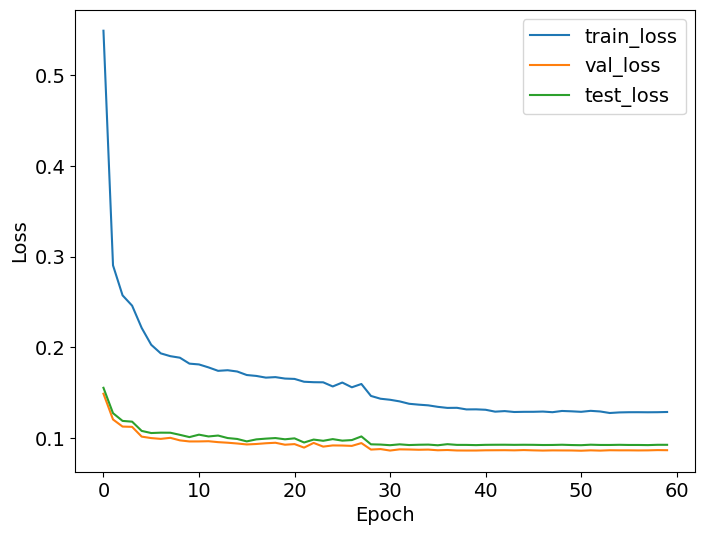

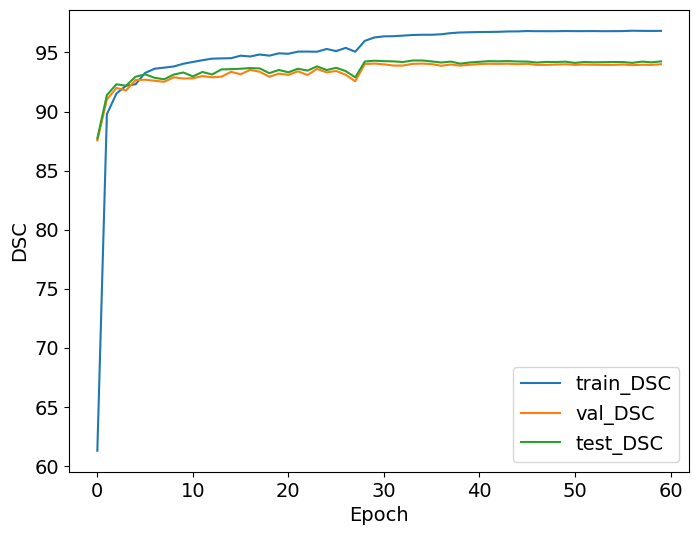

In [2]:
%run TrainUnet.py

c:\Users\User\anaconda3\envs\seg2d\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
c:\Users\User\anaconda3\envs\seg2d\lib\site-packages\fastonn\utils\utils.py:21: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


Train on gpu: True
1 gpus detected.
#############################################################
training using Attention_Super_FPN network
started fold 1
Initialized with Custom 

SuperONNLayer initialized with shifts: 2 True 1
SuperONNLayer initialized with shifts: 2 True 1
SuperONNLayer initialized with shifts: 2 True 1
SuperONNLayer initialized with shifts: 2 True 1
SuperONNLayer initialized with shifts: 2 True 1
SuperONNLayer initialized with shifts: 2 True 1
SuperONNLayer initialized with shifts: 2 True 1
SuperONNLayer initialized with shifts: 2 True 1
SuperONNLayer initialized with shifts: 2 True 1
SuperONNLayer initialized with shifts: 2 True 1
SuperONNLayer initialized with shifts: 2 True 1
model device: cuda
Combined Loss initatied with:
loss_types: ['SMP_DiceLoss', 'SMP_JaccardLoss'], weights: [0.5, 0.5]
Trainable parameters: 4.171998
Starting Training from Scratch.




Epoch: 0 	Training Loss: 0.6406 	Validation Loss: 0.2478 	 Test Loss: 0.2478
		Training DSC: 47.02% 	 Validation DSC: 58.70% 	 Test DSC: 59.70%



Epoch: 1 	Training Loss: 0.5103 	Validation Loss: 0.2263 	 Test Loss: 0.2248
		Training DSC: 59.29% 	 Validation DSC: 53.54% 	 Test DSC: 54.43%



Epoch: 2 	Training Loss: 0.4529 	Validation Loss: 0.2089 	 Test Loss: 0.2089
		Training DSC: 65.68% 	 Validation DSC: 59.72% 	 Test DSC: 61.90%


...


Epoch: 55 	Training Loss: 0.0957 	Validation Loss: 0.1319 	 Test Loss: 0.1272
		Training DSC: 96.58% 	 Validation DSC: 87.68% 	 Test DSC: 88.72%



Epoch: 56 	Training Loss: 0.0955 	Validation Loss: 0.1311 	 Test Loss: 0.1265
		Training DSC: 96.53% 	 Validation DSC: 86.83% 	 Test DSC: 87.96%



Epoch: 57 	Training Loss: 0.0909 	Validation Loss: 0.1313 	 Test Loss: 0.1273
		Training DSC: 96.83% 	 Validation DSC: 87.83% 	 Test DSC: 88.81%



Epoch: 58 	Training Loss: 0.0890 	Validation Loss: 0.1324 	 Test Loss: 0.1281
		Training DSC: 96.93% 	 Validation DSC: 87.84% 	 Test DSC: 88.89%



Epoch: 59 	Training Loss: 0.0887 	Validation Loss: 0.1316 	 Test Loss: 0.1273
		Training DSC: 96.93% 	 Validation DSC: 87.80% 	 Test DSC: 88.82%

Best epoch: 50 with loss: 0.1302 and DSC: 87.80%
22030.80 total seconds elapsed. 373.40 seconds per epoch.
Test Loss: 0.127,  Test Accuracy: 96.81%
Test IoU: 86.42,  Test DSC: 88.76
completed fold 1
#############################################################
Checkpoint File Removed!


          loss  Accuracy    IoU    DSC  IoU_1  DSC_1  IoU_2  DSC_2  IoU_3  \
fold_1   0.127     96.81  86.42  88.76  87.56  89.28  91.61  93.12   90.0   
Average  0.127     96.81  86.42  88.76  87.56  89.28  91.61  93.12   90.0   

         DSC_3  ...  IoU_11  DSC_11  IoU_12  DSC_12  IoU_13  DSC_13  IoU_14  \
fold_1   91.59  ...   92.98   94.06   91.56   92.75   76.74   80.06   91.53   
Average  91.59  ...   92.98   94.06   91.56   92.75   76.74   80.06   91.53   

         DSC_14  IoU_15  DSC_15  
fold_1    92.54   90.39   91.64  
Average   92.54   90.39   9

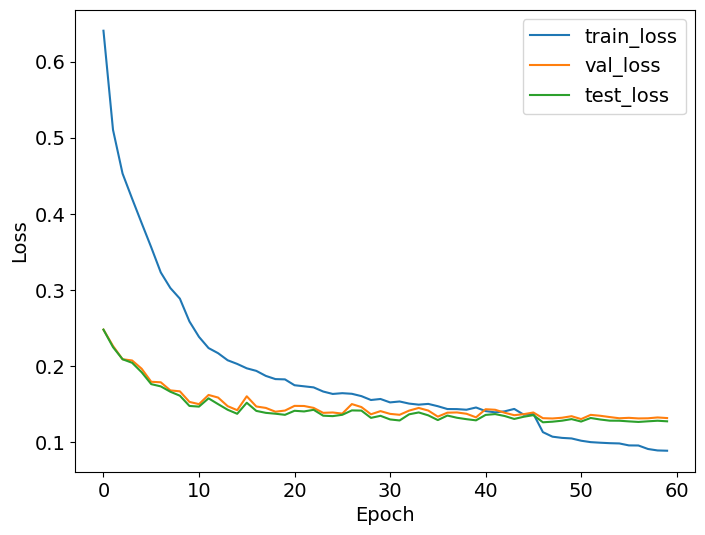

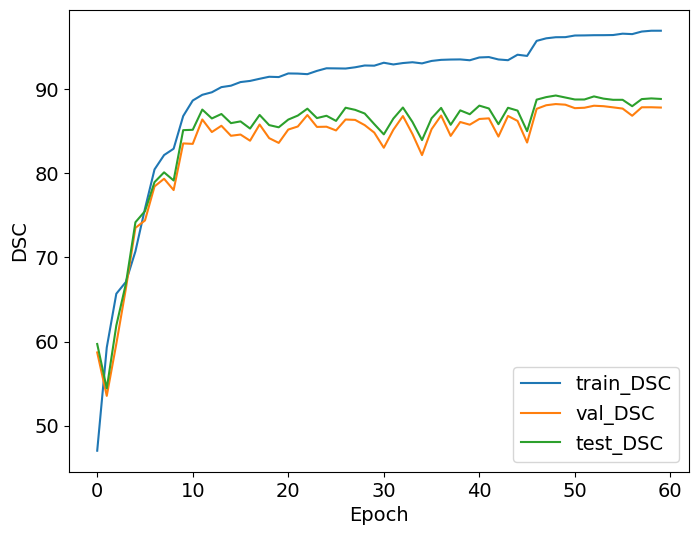

In [ ]:
%run TrainUnet.py

c:\Users\User\anaconda3\envs\seg2d\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
c:\Users\User\anaconda3\envs\seg2d\lib\site-packages\fastonn\utils\utils.py:21: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


Train on gpu: True
1 gpus detected.
#############################################################
training using densenet121*Unet network
started fold 1
Resuming training from checkpoint

model device: cuda
Combined Loss initatied with:
loss_types: ['SMP_DiceLoss', 'SMP_JaccardLoss'], weights: [0.5, 0.5]
Trainable parameters: 13.603536
Model has been trained for: 37 epochs.




Epoch: 37 	Training Loss: 0.1053 	Validation Loss: 0.0938 	 Test Loss: 0.0929
		Training DSC: 96.30% 	 Validation DSC: 92.43% 	 Test DSC: 92.71%



Epoch: 38 	Training Loss: 0.1082 	Validation Loss: 0.1006 	 Test Loss: 0.0993
		Training DSC: 96.12% 	 Validation DSC: 92.15% 	 Test DSC: 92.65%



Epoch: 39 	Training Loss: 0.1101 	Validation Loss: 0.0991 	 Test Loss: 0.0978
		Training DSC: 96.08% 	 Validation DSC: 92.68% 	 Test DSC: 93.14%


...


Epoch: 55 	Training Loss: 0.0794 	Validation Loss: 0.0912 	 Test Loss: 0.0886
		Training DSC: 97.61% 	 Validation DSC: 93.12% 	 Test DSC: 93.44%



Epoch: 56 	Training Loss: 0.0776 	Validation Loss: 0.0918 	 Test Loss: 0.0890
		Training DSC: 97.63% 	 Validation DSC: 93.10% 	 Test DSC: 93.42%



Epoch: 57 	Training Loss: 0.0761 	Validation Loss: 0.0912 	 Test Loss: 0.0889
		Training DSC: 97.64% 	 Validation DSC: 93.19% 	 Test DSC: 93.36%



Epoch: 58 	Training Loss: 0.0756 	Validation Loss: 0.0916 	 Test Loss: 0.0890
		Training DSC: 97.69% 	 Validation DSC: 93.12% 	 Test DSC: 93.35%



Epoch: 59 	Training Loss: 0.0730 	Validation Loss: 0.0908 	 Test Loss: 0.0882
		Training DSC: 97.76% 	 Validation DSC: 93.16% 	 Test DSC: 93.41%

Best epoch: 52 with loss: 0.0905 and DSC: 93.16%
6196.71 total seconds elapsed. 105.03 seconds per epoch.
Test Loss: 0.0878,  Test Accuracy: 97.00%
Test IoU: 91.4,  Test DSC: 93.38
completed fold 1
#############################################################
Checkpoint File Removed!


           loss  Accuracy   IoU    DSC  IoU_1  DSC_1  IoU_2  DSC_2  IoU_3  \
fold_1   0.0878      97.0  91.4  93.38   93.1  94.32  96.25  97.28  95.85   
Average  0.0878      97.0  91.4  93.38   93.1  94.32  96.25  97.28  95.85   

         DSC_3  ...  IoU_11  DSC_11  IoU_12  DSC_12  IoU_13  DSC_13  IoU_14  \
fold_1   96.92  ...   93.84   95.01   93.06   94.44   84.01   87.37   94.22   
Average  96.92  ...   93.84   95.01   93.06   94.44   84.01   87.37   94.22   

         DSC_14  IoU_15  DSC_15  
fold_1    95.07   94.86   95.87  
Average   95.07   94.86   95

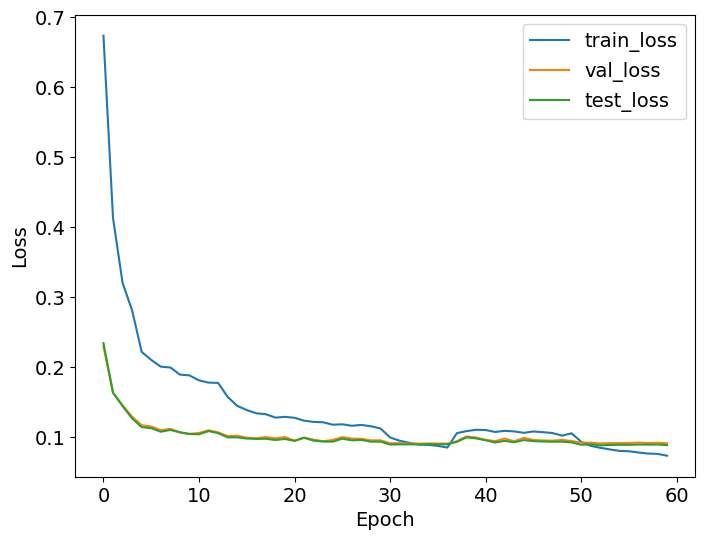

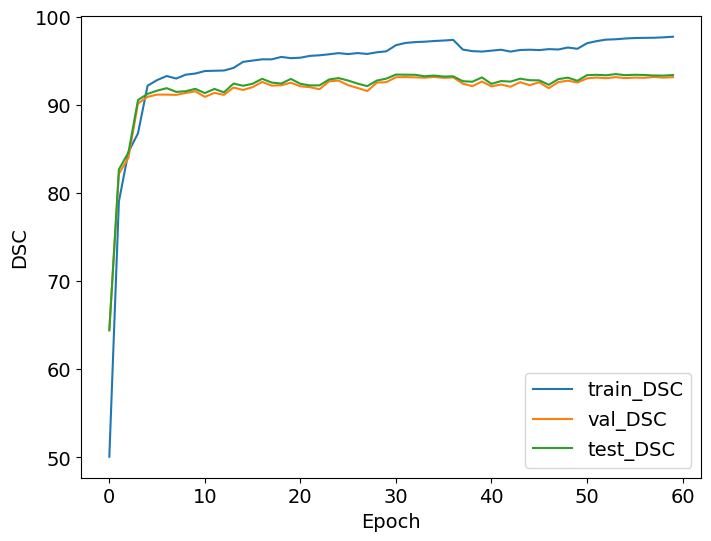

In [ ]:
%run TrainUnet.py

3-Custom evaluation

In [ ]:
import metric_evaluation_opt
gnd = '/content/Data/Test'
predict = '/content/drive/MyDrive/Rusab/Multiclass_test/Generated_mask/BinaryclassTest_Carotid_resnet18*SelfONN_Unet'
class_map = []
metric_evaluation_opt.evaluation(gnd, predict, save = True, reduction = 'micro', classes = 1, class_map = class_map, disregard_background = True)

#**Run your model on an exteranl dataset or re-generate the test results**


In [ ]:
%cd /content/2D_Segmentation

In [ ]:
#/content/drive/MyDrive/Rusab/Coronary_segmentation/
%%writefile config_test.py
# CNN test configuration file

##### DO NOT EDIT THESE LINES #####
config = {}
###################################

#### START EDITING FROM HERE ######
config['parentdir'] = '/content/'                                                        # main directory
config['ONN'] = True                                                                     # set to 'True' if you are using ONN
config['batch_size'] = 16                                                                # batch size, Change to fit hardware
config['in_channels'] = 3                                                                # 1 for gray scale x-rays, and 3 for RGB (3channel) x-rays
config['out_channels'] = 5                                                               # number of classes (Use 1 for binary, Use total number of classes with background for multiclass)
config['palette'] = [155, 38, 182, 14, 135, 204, 124, 252, 0, 255, 20, 147, 169, 169, 169, 5, 5, 5, 6, 6, 6, 7, 7, 7, 8, 8, 8, 9, 9, 9, 10, 10, 10, 11, 11, 11, 12, 12, 12, 13, 13, 13, 14, 14, 14, 15, 15, 15]
config['disregard_background'] = True                                                    # For Multi-Class Only : Whether to Disregard Background (0 Class) in metric calculation
config['calculate_loss_on_bg']  = False                                                  # For Multi-Class Only : Whether to calculate loss on background class
config['input_mean'] = [0.4451, 0.4431, 0.4012]                                             # provide 3 numbers for RGB images or 1 number for gray scale images in list format
config['input_std'] = [0.2162, 0.2093, 0.2245]                                             # provide 3 numbers for RGB images or 1 number for gray scale images in list format
config['num_folds'] = 1                                                                  # number of folds
config['class_weights'] = None                                                           # class weights for multi class masks, default: none
config['lossType'] = 'SMP_DiceLoss'
config['Resize_h'] = 256                                                                 # network input size
config['Resize_w'] = config['Resize_h']
# config['load_model'] = '/content/drive/Shareddrives/Rusab/Coronary_Angiogram/Results/MixTrain_densenet121*SelfONN_ResUnet/MixTrain_densenet121*SelfONN_ResUnet_fold_3.pt'        # specify full path of pretrained model pt file
config['load_model'] = False                                                             # specify path of pretrained model wieghts or set to False to train from scratch
config['Test_Mask'] = True                                                               # set to true if you have the test masks, to compute Evaluation metricies over test set
config['model_name'] = 'MulticlassTest_UNet_sanity'            # choose a unique name for result folder
config['decoder_attention'] = 'scse'                                                   #decoder attention type
config['seg_threshold'] = 0.5                                                           # Segmentation Threshold (Default 0.5)
config['new_name'] = 'MulticlassTest_UNet_sanity'                                                                 #specify a new folder name to save test results,
config['fold_to_run'] = [1,1] # define as [] to loop through all folds, or specify start and end folds i.e. [3, 5] or [5, 5]     # else set to False to overwrite test results genertaed by train code
##################

##################
config['generated_masks']  = "/content/drive/MyDrive/Rusab/Multiclass_test/" + 'Generated_mask'        # path to save generated_masks for test set
config['Results_path'] = "/content/drive/MyDrive/Rusab/Multiclass_test/" + "Results"                      # main results file
if config['new_name']:
    config['save_path'] = config['Results_path'] +'/'+ config['new_name']                                      # new save path
else:
    config['save_path'] = config['Results_path'] +'/'+ config['model_name']                                    # same save path used for training
##################


Test on Dataset

In [ ]:
!python TestUnet.py

In [ ]:
import metric_evaluation_opt
gnd = '/content/Data/Test'
predict = '/content/drive/MyDrive/Rusab/Multiclass_test/Generated_mask/BinaryclassTest_Carotid_resnet18*SelfONN_Unet'
class_map = []
metric_evaluation_opt.evaluation(gnd, predict, save = True, reduction = 'micro', classes = 1, class_map = class_map, disregard_background = True)

Colorize Predictions

In [ ]:
seg_type = 'binary' #'multiclass' for multiclass
predict_dir = r'..\..\..\..\Liver_Dataset\To_Rusab\Generated_mask\Adiba_CLAHE_densenet121_Unet_D_J'
color_output_dir = predict_dir + '/compare'

for i in range(1,6):
  gnd = '..\..\..\..\Liver_Dataset\To_Rusab\preprocessed\Data\Test'+ str(i) +'/masks'
  predict = predict_dir + '/fold_' + str(i)
  des = color_output_dir  + '/fold_'+ str(i)
  

  !python colorize_evaluation.py --gt $gnd --pred $predict --des $des --type $seg_type

Traceback (most recent call last):
  File "e:\Code Works\testing-2d-segmentation\new model\2D_Segmentation\2D_Segmentation\colorize_evaluation.py", line 31, in <module>
    img = cv2.imread(os.path.join(pred, os.listdir(pred)[0]), cv2.IMREAD_GRAYSCALE)
FileNotFoundError: [WinError 3] The system cannot find the path specified: '..\\..\\..\\..\\Liver_Dataset\\To_Rusab\\Generated_mask\\Adiba_CLAHE_densenet121_Unet_D_J/fold_1'
Traceback (most recent call last):
  File "e:\Code Works\testing-2d-segmentation\new model\2D_Segmentation\2D_Segmentation\colorize_evaluation.py", line 31, in <module>
    img = cv2.imread(os.path.join(pred, os.listdir(pred)[0]), cv2.IMREAD_GRAYSCALE)
FileNotFoundError: [WinError 3] The system cannot find the path specified: '..\\..\\..\\..\\Liver_Dataset\\To_Rusab\\Generated_mask\\Adiba_CLAHE_densenet121_Unet_D_J/fold_2'
Traceback (most recent call last):
  File "e:\Code Works\testing-2d-segmentation\new model\2D_Segmentation\2D_Segmentation\colorize_evaluation.py"

In [ ]:
color_output_dir

'E:\\Code Works\\Liver_Dataset\\To Rusab\\Generated_mask\\Adiba_dresnet50_MAnet_D_J\\compare'